# 📡 5.2 1D-CNN Classification Model

Este notebook explora una arquitectura de clasificación basada en **Redes Neuronales Convolucionales 1D (1D-CNN)** para la clasificación de embeddings de proteínas.

A diferencia de un MLP tradicional, una CNN puede capturar **patrones locales** o “motivos” a lo largo de la secuencia, combinando esta información con representaciones globales del embedding.

---

## 📋 Descripción general

El modelo trabaja con embeddings de proteínas y utiliza tres entradas principales:

- `X`: embeddings por residuo, con forma `(B, L, 768)`.
- `G`: embedding global/contextual de la secuencia, con forma `(B, 768)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura propuesta:

1. Aplica **Mean Pooling** sobre los embeddings por residuo `X`, respetando la máscara.
2. Procesa `X` mediante capas **Conv1d** enmascaradas.
3. Utiliza `BatchNorm1d`, activación `GELU` y `Dropout1d`.
4. Genera representaciones globales mediante:
   - **Max pooling**
   - **Average pooling**
5. Concatena:
   - características extraídas por la CNN,
   - embedding global `G`,
   - embedding agregado por mean pooling.
6. Clasifica mediante un MLP seguido de una capa lineal final.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura convolucional 1D**
   - Capas `Conv1d` sobre embeddings por residuo.
   - Normalización por lotes y activaciones `GELU`.
   - Pooling global mediante máximos y promedios.

2. **Experimentación con múltiples variantes**
   - `CNN_Small`
   - `CNN_Medium`
   - `CNN_Large`

3. **Pipeline completo de entrenamiento**
   - `FocalLoss`
   - Optimizador `AdamW`
   - `ReduceLROnPlateau`
   - Early stopping
   - Evaluación en validación con GPU

4. **Comparación de modelos**
   - Accuracy
   - F1-score
   - MCC
   - ROC-AUC
   - PR-AUC

5. **Exportación de artefactos**
   - Checkpoints de modelos
   - Tabla comparativa
   - Curvas de entrenamiento
   - Métricas finales en JSON

## 📦 Importación de dependencias y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros CNN

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset") 
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT = DATA_DIR / "train_dataset.pt"
VAL_PT   = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 128
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 768      # Dimensión de los embeddings

# ========== ARCHITECTURAS A COMPARAR ==========
ARCHITECTURES = [
    {
        "name": "CNN_Small",
        "conv_channels": [128, 64],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "CNN_Medium",
        "conv_channels": [256, 128],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "CNN_Large",
        "conv_channels": [512, 256, 128],
        "kernel_sizes": [3, 5, 5],
        "mlp_hidden": [256, 128],
        "dropout": 0.4,
        "lr": 5e-4,  # Learning rate ligeramente menor para una red más grande
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['mlp_hidden']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - CNN_Small: hidden=[128], dropout=0.3
  - CNN_Medium: hidden=[128], dropout=0.4
  - CNN_Large: hidden=[256, 128], dropout=0.4


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Gated Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError(pt_path)
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=108, val=33
   ✅ X_b: (128, 100, 768) | G_b: (128, 768)


## 🔑 Mecanismo `MeanPooler`

In [9]:
class MeanPooler(nn.Module):
    """
    Mean pooling simple con máscara.
    
    Input:
      - X: (B, L, D) embeddings por residuo
      - M: (B, L) máscara binaria (1 = residuo válido, 0 = padding)
    
    Output:
      - E: (B, D) embedding agregado por secuencia
    """
    def __init__(self, input_dim: int):
        super().__init__()
        # No hay parámetros aprendibles

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        mask = M.unsqueeze(-1)                        # (B, L, 1)
        summed = (X * mask).sum(dim=1)               # (B, D)
        counts = mask.sum(dim=1).clamp(min=1e-8)     # (B, 1)
        return summed / counts                        # (B, D)

## 🏗️ Arquitectura `Conv1DClassifier` y Verificación

In [10]:
class MeanConv1DClassifier(nn.Module):
    """1D-CNN classifier con Mean Pooling."""

    def __init__(self, input_dim: int, conv_channels: List[int],
                 kernel_sizes: List[int], mlp_hidden: List[int],
                 dropout: float = 0.3):
        super().__init__()

        # ✅ Mean Pooling
        self.pooler = MeanPooler(input_dim=input_dim)

        self.convs = nn.ModuleList()
        in_channels = input_dim
        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=k_size, padding="same"),
                nn.BatchNorm1d(out_channels),
                nn.GELU(),
                nn.Dropout1d(dropout),
            ))
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        # ✅ clf_in_dim = CNN + Global + MeanPooled
        clf_in_dim = cnn_out_dim + input_dim + input_dim

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # Mean pooling global
        E = self.pooler(X, M)  # (B, D)

        # CNN
        x_cnn = X.transpose(1, 2)  # (B, D, L)
        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        combined = torch.cat([cnn_features, G, E], dim=1)
        x = self.mlp(combined)
        return self.classifier(x)


def build_mean_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanConv1DClassifier(
        input_dim, config["conv_channels"], config["kernel_sizes"],
        config["mlp_hidden"], config["dropout"],
    )

## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model, loader, device):

    model.eval()

    logits_list = []
    y_list = []

    for Xb, Gb, Mb, yb in loader:

        Xb = Xb.to(device)
        Gb = Gb.to(device)
        Mb = Mb.to(device)

        logits = model(Xb, Gb, Mb)

        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))

    proba = torch.sigmoid(torch.tensor(np.concatenate(logits_list))).numpy()
    y = np.concatenate(y_list)

    return proba, y

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device,
                max_epochs=MAX_EPOCHS, patience=PATIENCE):

    seed_everything(SEED)

    model = build_mean_cnn_model(config, input_dim).to(device)

    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0.0
        n = 0

        for Xb, Gb, Mb, yb in train_loader:

            Xb = Xb.to(device)
            Gb = Gb.to(device)
            Mb = Mb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(Xb, Gb, Mb)

            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)

        train_loss /= n

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0.0
        n = 0

        with torch.no_grad():

            for Xb, Gb, Mb, yb in val_loader:

                Xb = Xb.to(device)
                Gb = Gb.to(device)
                Mb = Mb.to(device)
                yb = yb.to(device)

                logits = model(Xb, Gb, Mb)

                loss = criterion(logits, yb)

                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)

        val_loss /= n

        scheduler.step(val_loss)

        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); 
        history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:

            best_val_loss = val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_epoch = epoch
            no_improve = 0

        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    n_params = sum(p.numel() for p in res["model"].parameters())

    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({
        "model_name": config["name"],
        "state_dict": res["model"].state_dict(),
        "config": config,
        "input_dim": INPUT_DIM
    }, ckpt_path)

    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "model": res["model"],
        "config": config,
        "history": res["history"],
    })

    
    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando CNN_Small ---
E01 | TL: 0.0596 | VL: 0.0523 | Val MCC: 0.7744 | B_ep: 1
E02 | TL: 0.0486 | VL: 0.0510 | Val MCC: 0.7831 | B_ep: 2
E03 | TL: 0.0451 | VL: 0.0475 | Val MCC: 0.7968 | B_ep: 3
E04 | TL: 0.0412 | VL: 0.0545 | Val MCC: 0.7934 | B_ep: 3
E05 | TL: 0.0387 | VL: 0.0473 | Val MCC: 0.8035 | B_ep: 5
E06 | TL: 0.0354 | VL: 0.0474 | Val MCC: 0.8042 | B_ep: 5
E07 | TL: 0.0331 | VL: 0.0598 | Val MCC: 0.7289 | B_ep: 5
E08 | TL: 0.0315 | VL: 0.0524 | Val MCC: 0.8136 | B_ep: 5
E09 | TL: 0.0278 | VL: 0.0521 | Val MCC: 0.8133 | B_ep: 5
E10 | TL: 0.0256 | VL: 0.0506 | Val MCC: 0.8091 | B_ep: 5
E11 | TL: 0.0238 | VL: 0.0521 | Val MCC: 0.8127 | B_ep: 5
E12 | TL: 0.0185 | VL: 0.0564 | Val MCC: 0.8235 | B_ep: 5
E13 | TL: 0.0147 | VL: 0.0606 | Val MCC: 0.8225 | B_ep: 5
E14 | TL: 0.0143 | VL: 0.0666 | Val MCC: 0.8241 | B_ep: 5
E15 | TL: 0.0111 | VL: 0.0681 | Val MCC: 0.8227 | B_ep: 5
E16 | TL: 0.0113 | VL: 0.0796 | Val MCC: 0.8229 | B_ep: 5
E17 | TL: 0.0104 | VL: 0.0831 | Val MCC: 0

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "lstm_architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
        Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC
0   CNN_Small   549953           5  0.047324  0.901405  0.890621  0.803532     0.960573    0.965421
1  CNN_Medium   984705           7  0.048107  0.900921  0.891541  0.801576     0.959391    0.964227
2   CNN_Large  2494337           4  0.047571  0.898014  0.887403  0.796271     0.958949    0.964063

Saved

🏆 Best model: CNN_Small


## 📈 Visualización: Curvas de Entrenamiento Individuales

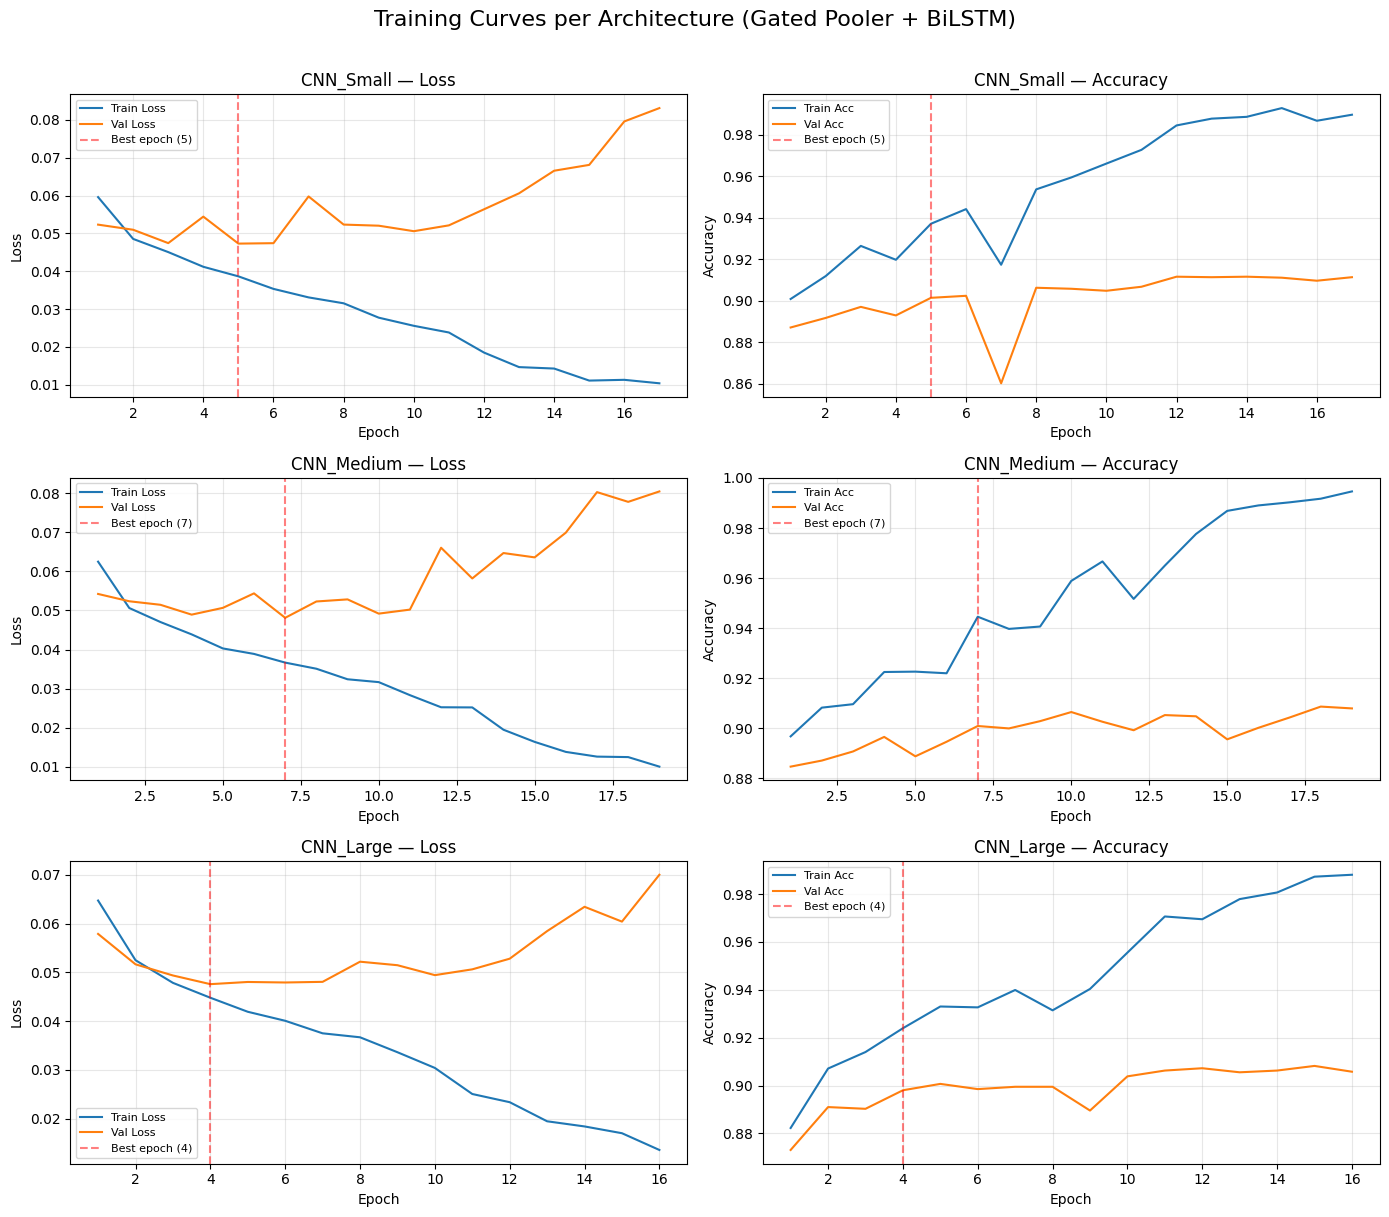

Saved: /kaggle/working/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler + BiLSTM)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

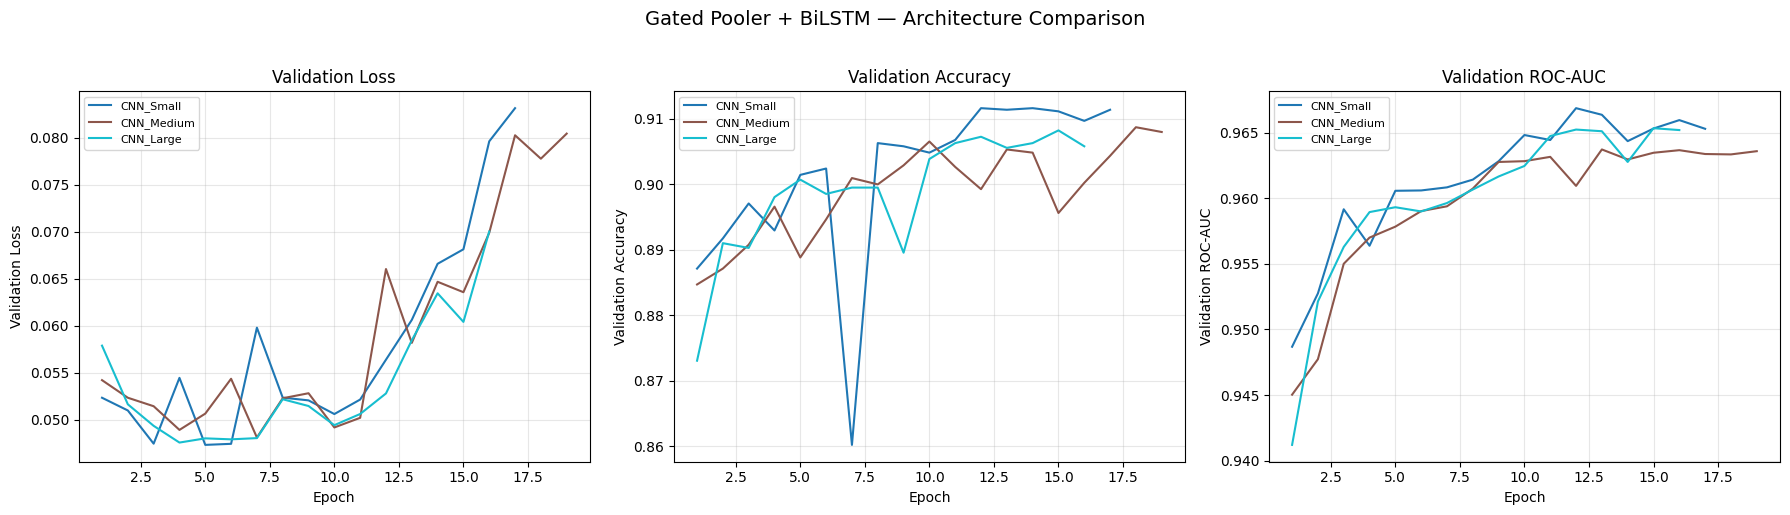

Saved: /kaggle/working/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler + BiLSTM — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

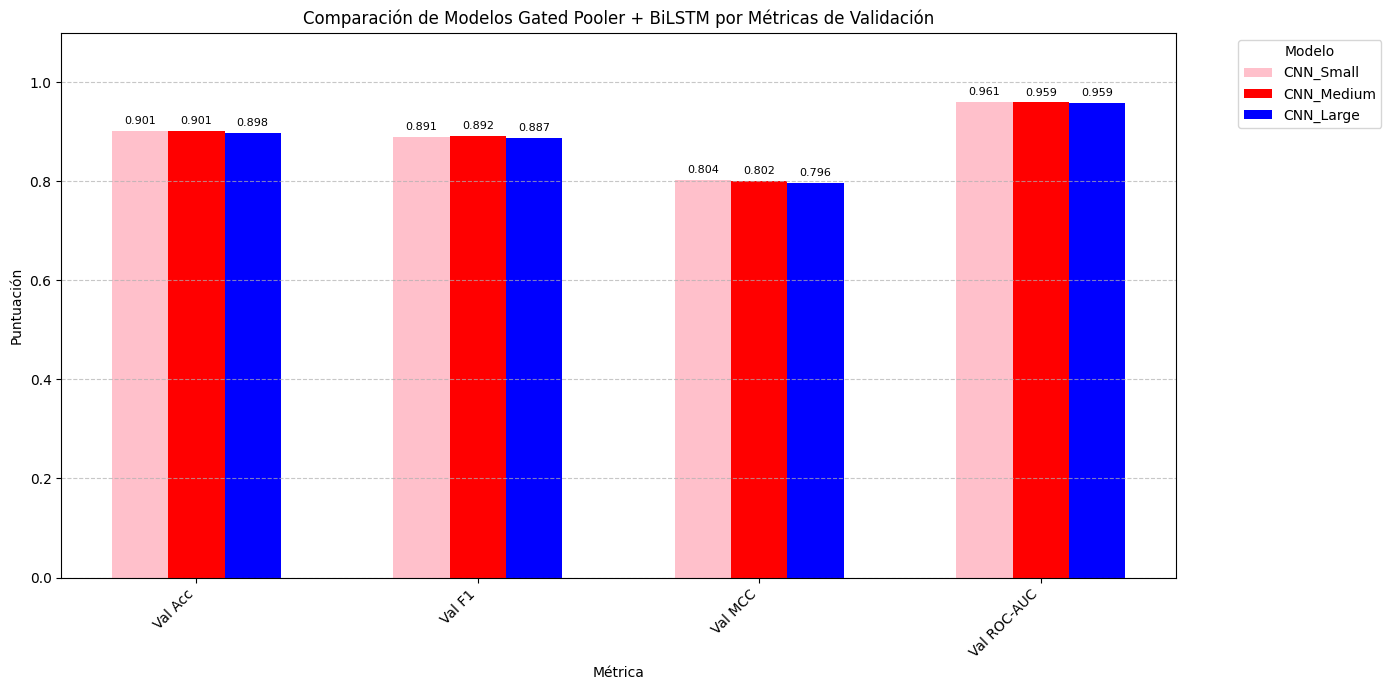

Saved: /kaggle/working/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['pink', 'red', 'blue', 'violet']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + BiLSTM por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: CNN_Small
   Parameters: 549,953
   Best epoch: 5
   Val loss:   0.047324

Saved:
  Checkpoint:    /kaggle/working/best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión final: mejor modelo

Tras comparar las arquitecturas `CNN_Small`, `CNN_Medium` y `CNN_Large`, el mejor modelo fue **CNN_Small**, al obtener el mejor equilibrio entre rendimiento, estabilidad y eficiencia.

### 📊 Resultados principales del mejor modelo

- **Modelo ganador:** `CNN_Small`
- **Parámetros:** 549,953
- **Mejor época:** 5
- **Val Loss:** 0.0473
- **Val Accuracy:** 0.9014
- **Val F1:** 0.8906
- **Val MCC:** 0.8035
- **Val ROC-AUC:** 0.9606
- **Val PR-AUC:** 0.9654

### 🧠 Interpretación

`CNN_Small` logró un rendimiento competitivo y ligeramente superior al de las variantes más grandes, con una arquitectura más ligera y eficiente. Esto sugiere que, para esta tarea, no es necesario aumentar excesivamente la capacidad del modelo para obtener una buena generalización.

Las arquitecturas `CNN_Medium` y `CNN_Large` incrementaron el número de parámetros, pero no produjeron mejoras consistentes suficientes como para justificar su mayor costo computacional.

### 📦 Artefactos generados

Los resultados y artefactos finales incluyen:

- `best_model_final.pth`
- `best_model_training_log.csv`
- `best_model_val_metrics.json`
- tabla comparativa de arquitecturas
- curvas de entrenamiento
- gráfico de barras comparativo

**Conclusión:**  
La arquitectura **1D-CNN + Mean Pooling**, en su variante **CNN_Small**, ofrece una solución robusta, eficiente y bien balanceada para la clasificación de embeddings de proteínas en este experimento.